In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_excel('ev_final.xlsx')

In [ ]:
df.head().T

,0,1,2,3,4
uid,STATIC12,STATIC14,STATIC15,STATIC16,STATIC17
name,GensolCharge Pvt. Ltd.,REIL,REIL,REIL,BluSmart
vendor_name,GensolCharge Pvt. Ltd.,REIL,REIL,REIL,BluSmart
address,"NDSE Grid, BRPL South Extension",Scada office kalka ji,Ashram Chowk Mathura Road,Nizamuddin Railway station,"BSES Bhawan, Nehru Place, New Delhi 110048"
latitude,28.568238,28.541995,28.571189,28.588991,28.549427
longitude,77.219666,77.260583,77.259806,77.25324,77.254636
city,Delhi,Delhi,Delhi,Delhi,Delhi
country,India,India,India,India,India
open,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00
close,23:59:59,23:59:59,23:59:59,23:59:59,23:59:59


In [ ]:
df.columns

Index([            'uid',            'name',     'vendor_name',
               'address',        'latitude',       'longitude',
                  'city',         'country',            'open',
                 'close',        'logo_url',           'staff',
         'payment_modes', 'contact_numbers',    'station_type',
           'postal_code',            'zone',                 0,
             'available',        'capacity',   'cost_per_unit',
            'power_type',           'total',            'type',
          'vehicle_type'],
      dtype='object')

In [ ]:
df.shape

(2705, 25)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2705 entries, 0 to 2704
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   uid              2705 non-null   object 
 1   name             2705 non-null   object 
 2   vendor_name      2705 non-null   object 
 3   address          2705 non-null   object 
 4   latitude         2705 non-null   float64
 5   longitude        2705 non-null   float64
 6   city             2705 non-null   object 
 7   country          2705 non-null   object 
 8   open             2705 non-null   object 
 9   close            2705 non-null   object 
 10  logo_url         2238 non-null   object 
 11  staff            2705 non-null   object 
 12  payment_modes    2705 non-null   object 
 13  contact_numbers  2705 non-null   object 
 14  station_type     2705 non-null   object 
 15  postal_code      2705 non-null   int64  
 16  zone             2410 non-null   object 
 17  0             

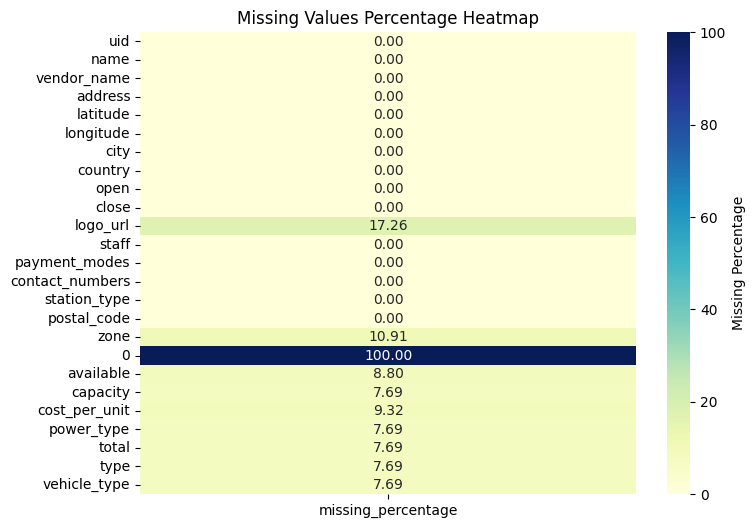

In [ ]:
# Calculate the percentage of missing values for each column
missing_percentage = df.isnull().mean() * 100

# Create a DataFrame with missing percentage information
missing_info = pd.DataFrame({'column': df.columns, 'missing_percentage': missing_percentage})

# Create a heatmap grid highlighting missing values percentage
plt.figure(figsize=(8, 6))
sns.heatmap(missing_info[['missing_percentage']], cmap='YlGnBu', annot=True, fmt='.2f', cbar_kws={'label': 'Missing Percentage'})
plt.title('Missing Values Percentage Heatmap')
plt.show()

In [ ]:
df['capacity'].fillna('0 kW', inplace=True)

# Replace 'Delhi' with 'New Delhi' in the 'city' column
df['city'] = df['city'].replace('Delhi', 'New Delhi')

# Make data consistent
df['staff'] = df['staff'].replace('Staffed', 'staffed')
df['staff'] = df['staff'].replace('UnStaffed', 'unstaffed')
df['staff'] = df['staff'].replace('Unstaffed', 'unstaffed')

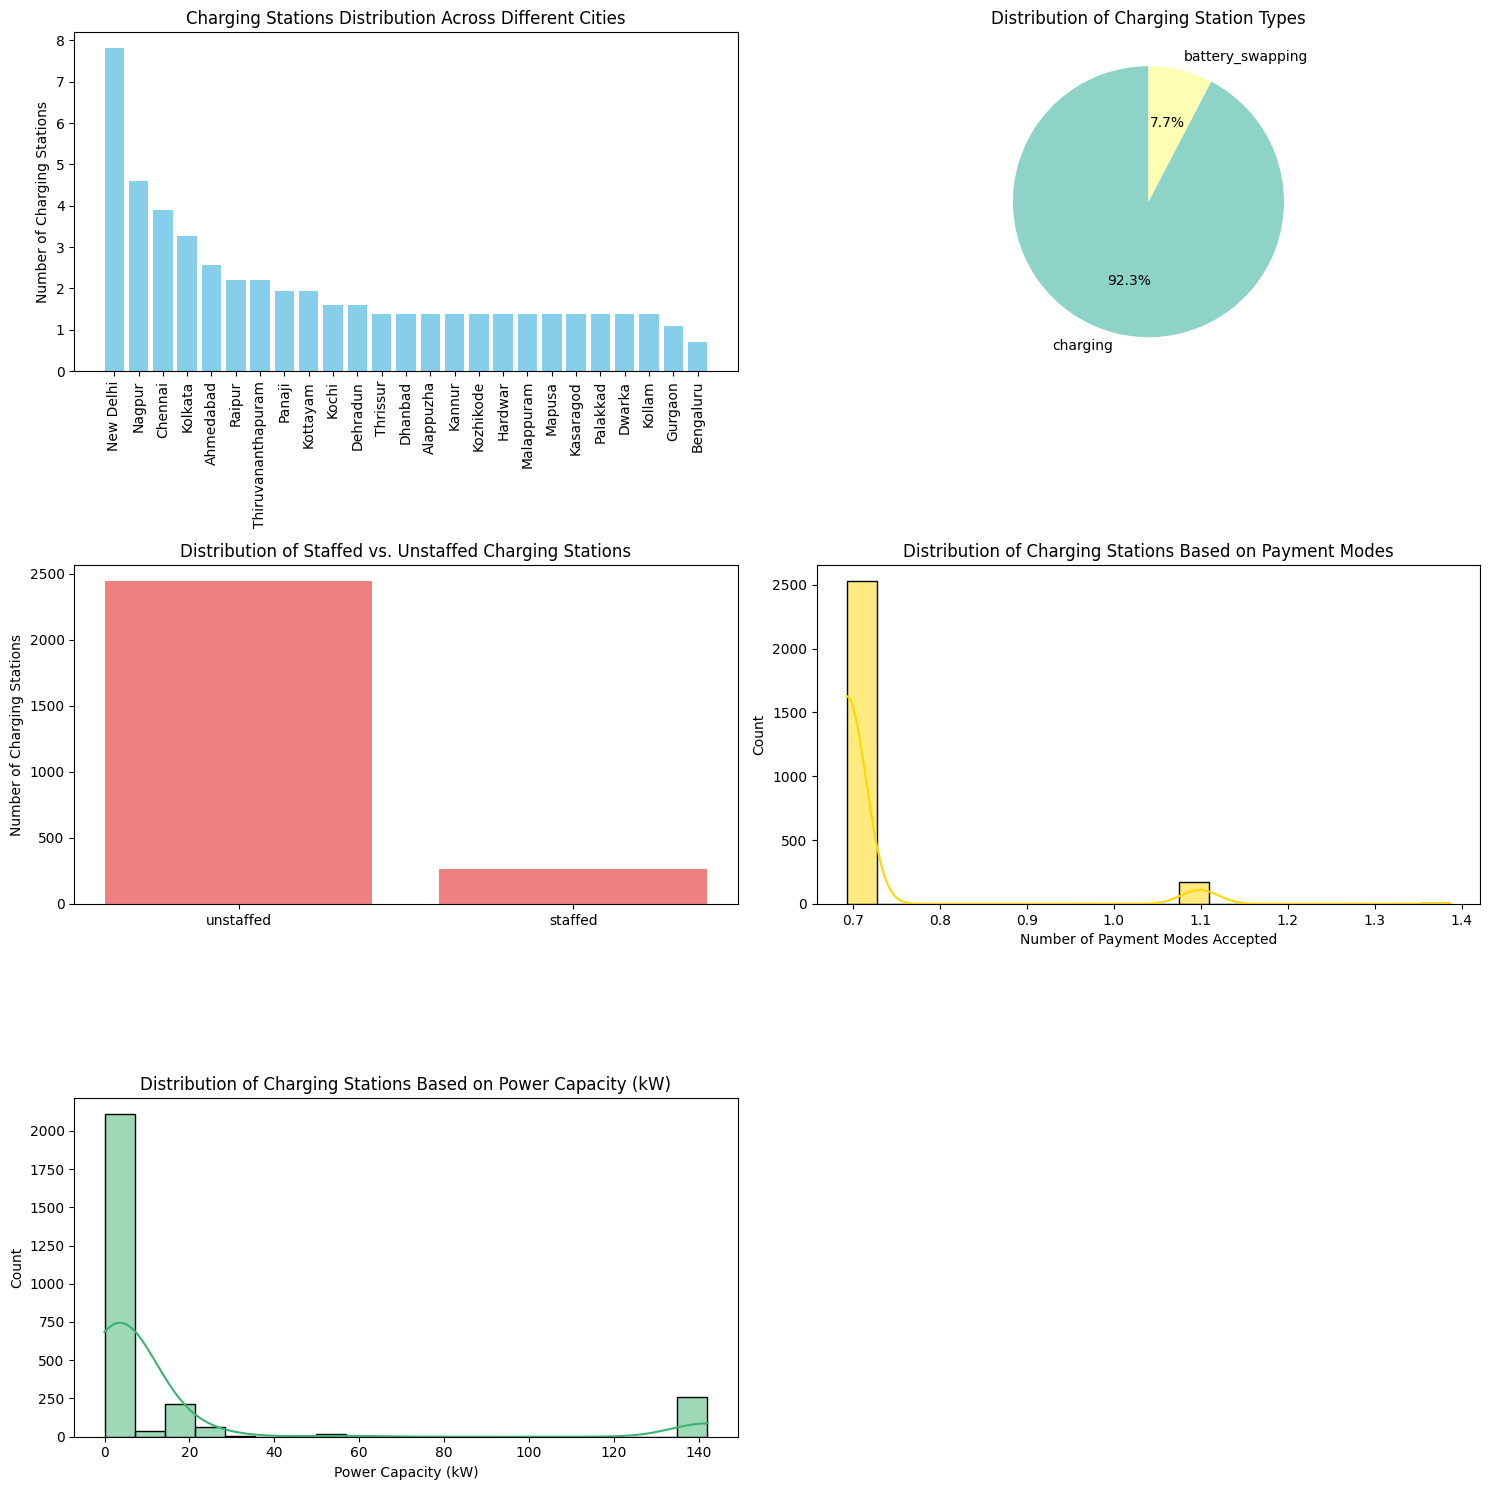

In [ ]:
# Set up subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# 1. Check the distribution of charging stations across different cities in India.
city_distribution = df['city'].value_counts()
city_distribution = np.log1p(city_distribution)
axes[0, 0].bar(city_distribution.index, city_distribution.values, color='skyblue')
axes[0, 0].set_title('Charging Stations Distribution Across Different Cities')
axes[0, 0].set_ylabel('Number of Charging Stations')
axes[0, 0].tick_params(axis='x', rotation=90)

# 2. Explore the distribution of charging station types.
station_type_distribution = df['station_type'].value_counts()
axes[0, 1].pie(station_type_distribution, labels=station_type_distribution.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3'))
axes[0, 1].set_title('Distribution of Charging Station Types')

# 3. Explore the distribution of stations that are staffed vs. unstaffed.
staff_distribution = df['staff'].value_counts()
axes[1, 0].bar(staff_distribution.index, staff_distribution.values, color='lightcoral')
axes[1, 0].set_title('Distribution of Staffed vs. Unstaffed Charging Stations')
axes[1, 0].set_ylabel('Number of Charging Stations')

# 4. Analyze the distribution of charging stations based on payment modes accepted.
payment_modes_distribution = df['payment_modes'].apply(lambda x: len(str(x).split(', ')) if pd.notnull(x) else 0)
payment_modes_distribution = np.log1p(payment_modes_distribution)
sns.histplot(payment_modes_distribution, bins=20, kde=True, color='gold', ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Charging Stations Based on Payment Modes')
axes[1, 1].set_xlabel('Number of Payment Modes Accepted')
df['capacity'] = df['capacity'].replace({'kW': ''}, regex=True)
df['capacity'] = pd.to_numeric(df['capacity'], errors='coerce')
sns.histplot(df['capacity'], bins=20, kde=True, color='mediumseagreen', ax=axes[2, 0])
axes[2, 0].set_title('Distribution of Charging Stations Based on Power Capacity (kW)')
axes[2, 0].set_xlabel('Power Capacity (kW)')
fig.delaxes(axes[2, 1])
plt.tight_layout()
plt.show()

        open               close        duration
0 2025-02-16 2025-02-16 23:59:59 0 days 23:59:59
1 2025-02-16 2025-02-16 23:59:59 0 days 23:59:59
2 2025-02-16 2025-02-16 23:59:59 0 days 23:59:59
3 2025-02-16 2025-02-16 23:59:59 0 days 23:59:59
4 2025-02-16 2025-02-16 23:59:59 0 days 23:59:59


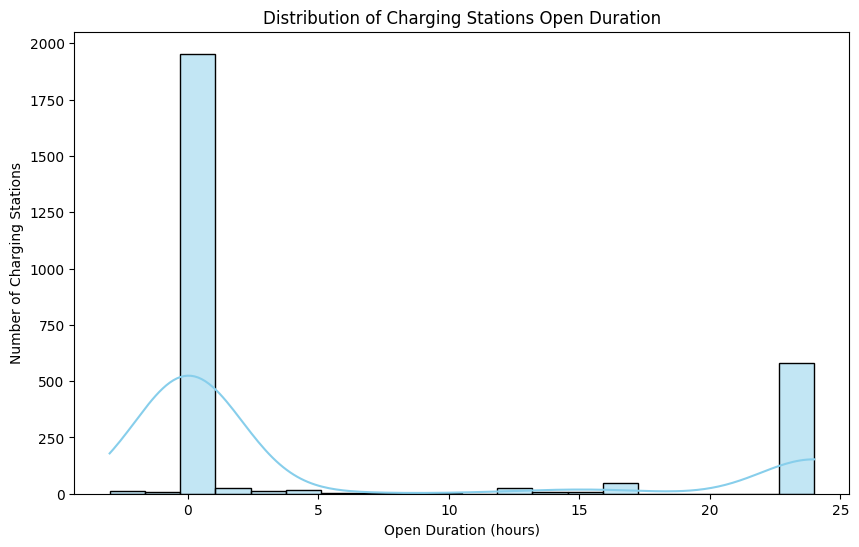

In [ ]:

df['open'] = pd.to_datetime(df['open'])
df['close'] = pd.to_datetime(df['close'])
df['duration'] = df['close'] - df['open']
print(df[['open', 'close', 'duration']].head())
plt.figure(figsize=(10, 6))
sns.histplot(df['duration'].dt.total_seconds() / 3600, bins=20, kde=True, color='skyblue')
plt.title('Distribution of Charging Stations Open Duration')
plt.xlabel('Open Duration (hours)')
plt.ylabel('Number of Charging Stations')
plt.show()

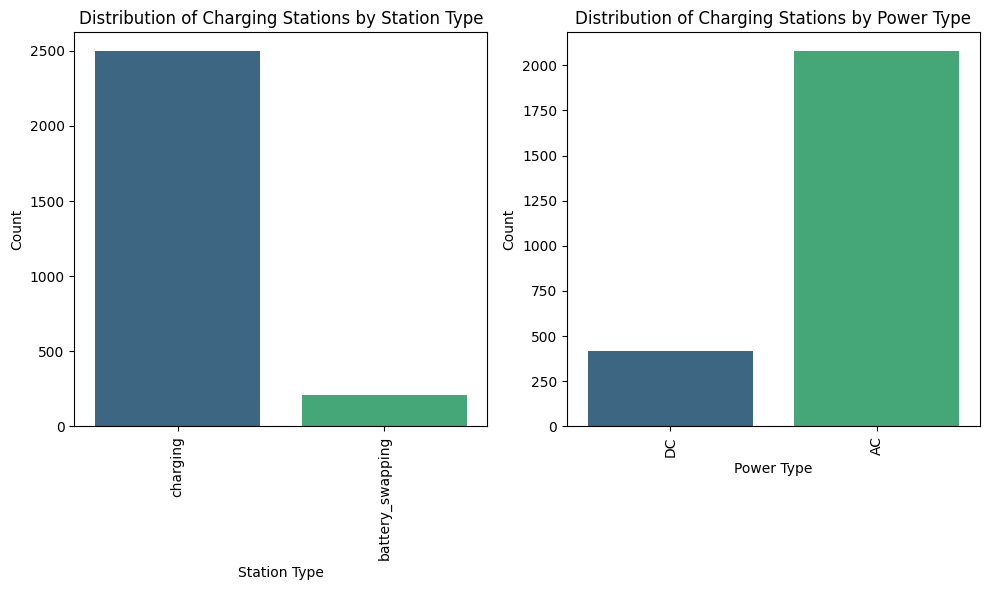

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
sns.countplot(x='station_type', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Charging Stations by Station Type')
axes[0].set_xlabel('Station Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90)
sns.countplot(x='power_type', data=df, palette='viridis', ax=axes[1])
axes[1].set_title('Distribution of Charging Stations by Power Type')
axes[1].set_xlabel('Power Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

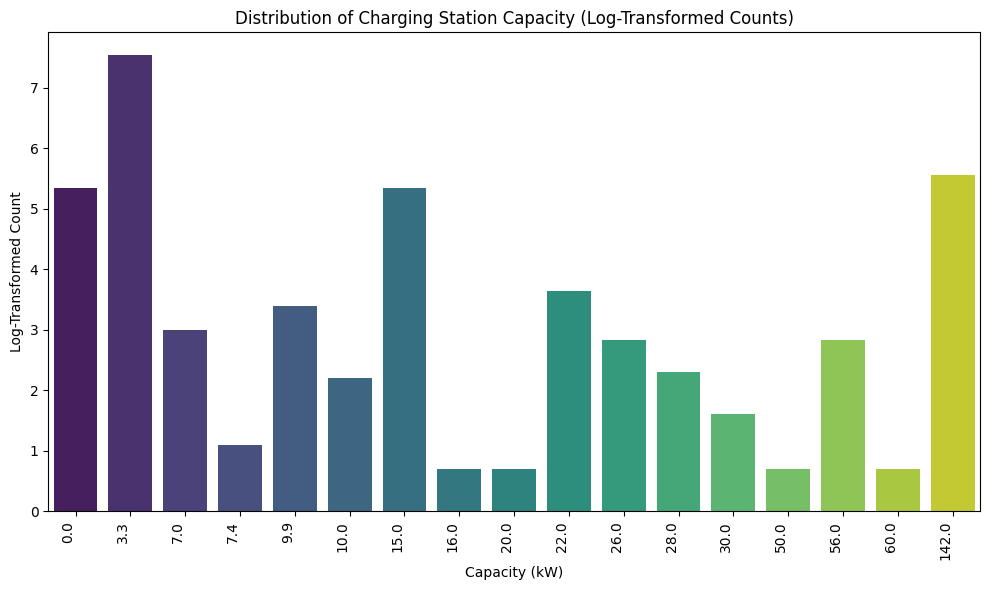

In [ ]:
capacity_counts = df['capacity'].value_counts()
log_counts = np.log1p(capacity_counts)
plt.figure(figsize=(10, 6))
sns.barplot(x=log_counts.index, y=log_counts.values, palette='viridis')
plt.title('Distribution of Charging Station Capacity (Log-Transformed Counts)')
plt.xlabel('Capacity (kW)')
plt.ylabel('Log-Transformed Count')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

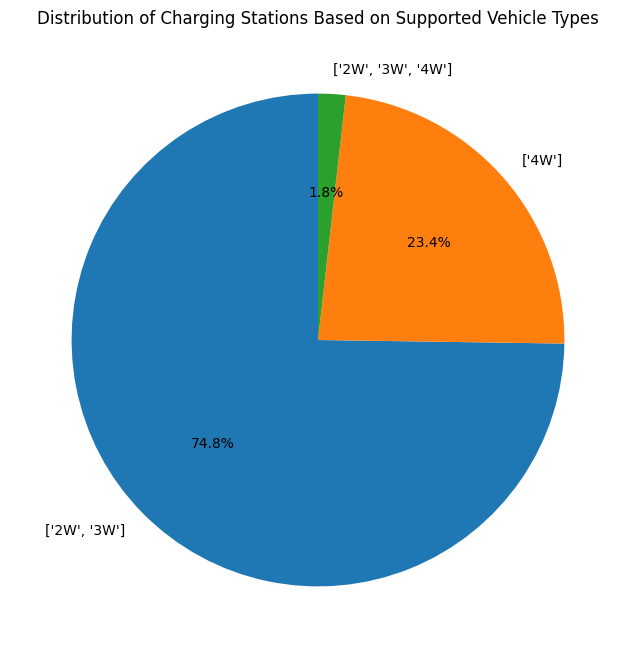

In [ ]:

vehicle_type_counts = df['vehicle_type'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(vehicle_type_counts, labels=vehicle_type_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Charging Stations Based on Supported Vehicle Types')
plt.show()

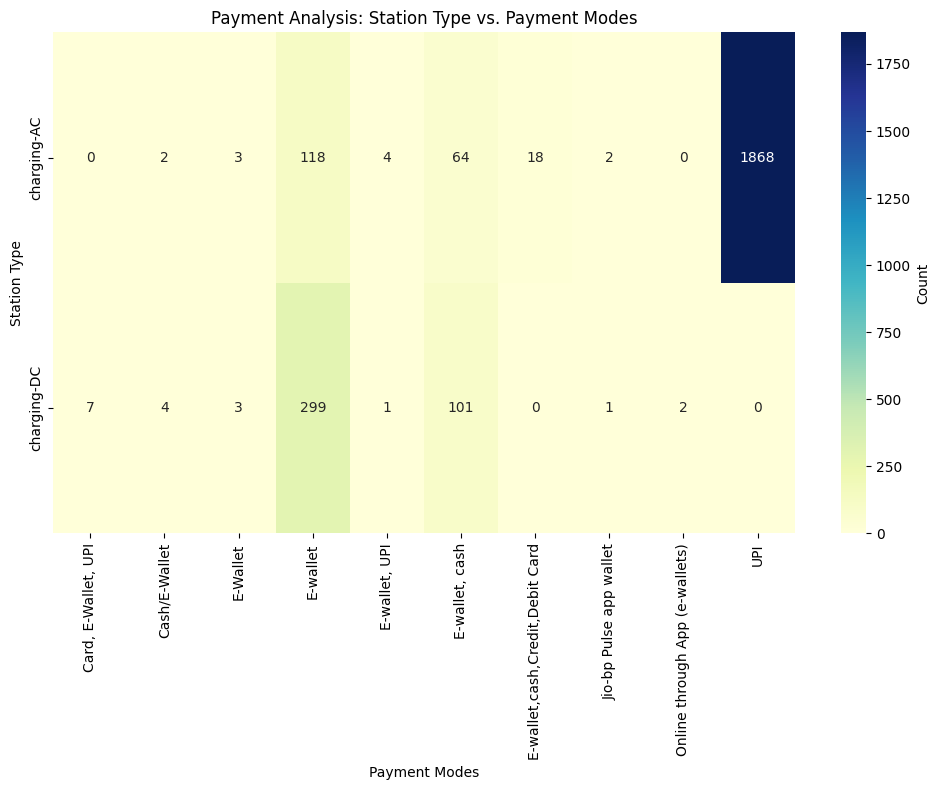

In [ ]:

payment_pivot = df.pivot_table(index=['station_type', 'power_type'], columns='payment_modes', values='vehicle_type', aggfunc='count', fill_value=0)
plt.figure(figsize=(10, 8))
sns.heatmap(payment_pivot, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Count'})
plt.title('Payment Analysis: Station Type vs. Payment Modes')
plt.xlabel('Payment Modes')
plt.ylabel('Station Type')
plt.tight_layout()
plt.show()

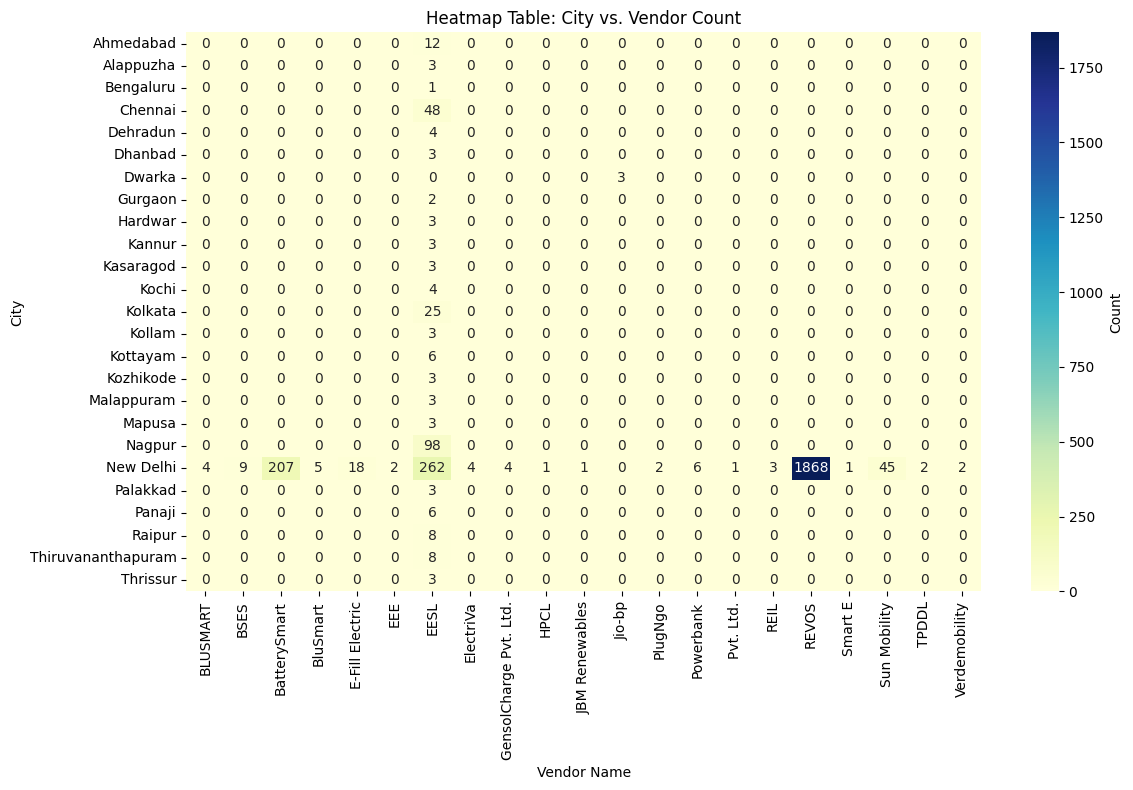

In [ ]:

city_vendor_pivot = df.pivot_table(index='city', columns='vendor_name', values='uid', aggfunc='count', fill_value=0)

# Create a heatmap table
plt.figure(figsize=(12, 8))
sns.heatmap(city_vendor_pivot, annot=True, cmap='YlGnBu', cbar_kws={'label': 'Count'}, fmt='g')
plt.title('Heatmap Table: City vs. Vendor Count')
plt.xlabel('Vendor Name')
plt.ylabel('City')
plt.tight_layout()
plt.show()

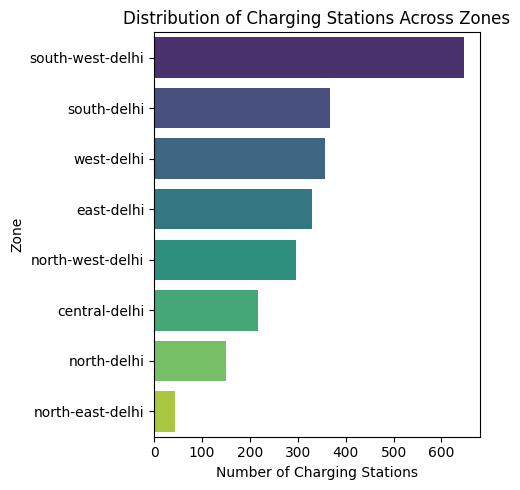

In [ ]:

zone_counts = df['zone'].value_counts()
sorted_zones = zone_counts.sort_values(ascending=False).index
plt.figure(figsize=(5, 5))
sns.countplot(y='zone', data=df, order=sorted_zones, palette='viridis')
plt.title('Distribution of Charging Stations Across Zones')
plt.ylabel('Zone')
plt.xlabel('Number of Charging Stations')
plt.tight_layout()
plt.show()

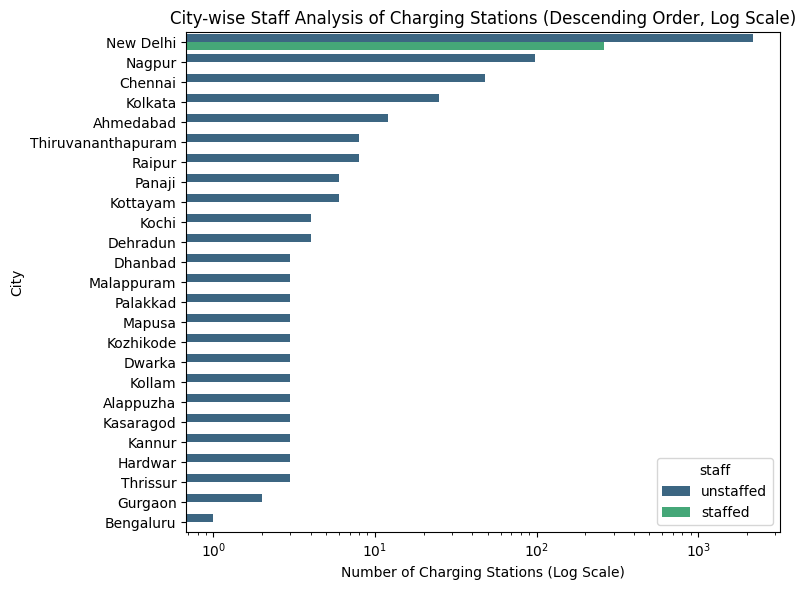

In [ ]:

city_station_counts = df.groupby('city')['uid'].count().reset_index()
sorted_cities = city_station_counts.sort_values(by='uid', ascending=False)['city']
plt.figure(figsize=(8, 6))
sns.countplot(y='city', hue='staff', data=df, order=sorted_cities, palette='viridis')
plt.xscale('log')

plt.title('City-wise Staff Analysis of Charging Stations (Descending Order, Log Scale)')
plt.ylabel('City')
plt.xlabel('Number of Charging Stations (Log Scale)')
plt.tight_layout()
plt.show()

In [ ]:
import folium
from folium.plugins import MarkerCluster


# Create a map centered around the mean latitude and longitude
map_center = [df['latitude'].mean(), df['longitude'].mean()]
charging_map = folium.Map(location=map_center, zoom_start=5)

# Create a MarkerCluster to group nearby markers
marker_cluster = MarkerCluster().add_to(charging_map)

# Add markers for each charging station
for index, row in df.iterrows():
    popup_text = f"<b>{row['name']}</b><br>Vendor: {row['vendor_name']}<br>Contact: {', '.join(map(str, row['contact_numbers']))}"
    folium.Marker([row['latitude'], row['longitude']], popup=popup_text).add_to(marker_cluster)

charging_map

In [ ]:

df['open'] = pd.to_datetime(df['open'])
df['close'] = pd.to_datetime(df['close'])
df['operational_hours'] = (df['close'] - df['open']).dt.total_seconds() / 3600
def get_peak_hours(row):
    open_time = row['open']
    close_time = row['close']
    mid_time = open_time + (close_time - open_time) / 2  # Midpoint of operational time

    # Assign morning or evening peak hours
    if mid_time.hour <= 12:
        return "9-11 AM"
    else:
        return "5-7 PM"

df['peak_hours'] = df.apply(get_peak_hours, axis=1)
peak_hours_by_city = df.groupby(['city', 'peak_hours']).size().reset_index(name='station_count')
peak_hours_by_city = peak_hours_by_city.sort_values(by=['city', 'station_count'], ascending=[True, False])
print("Peak Charging Hours by City:")
print(peak_hours_by_city)


Peak Charging Hours by City:
                  city peak_hours  station_count
0            Ahmedabad    9-11 AM             12
1            Alappuzha    9-11 AM              3
2            Bengaluru    9-11 AM              1
3              Chennai    9-11 AM             48
4             Dehradun    9-11 AM              4
5              Dhanbad    9-11 AM              3
6               Dwarka    9-11 AM              3
7              Gurgaon    9-11 AM              2
8              Hardwar    9-11 AM              3
9               Kannur    9-11 AM              3
10           Kasaragod    9-11 AM              3
11               Kochi    9-11 AM              4
12             Kolkata    9-11 AM             25
13              Kollam    9-11 AM              3
14            Kottayam    9-11 AM              6
15           Kozhikode    9-11 AM              3
16          Malappuram    9-11 AM              3
17              Mapusa    9-11 AM              3
18              Nagpur    9-11 AM       

In [ ]:

df['open'] = pd.to_datetime(df['open'])
df['close'] = pd.to_datetime(df['close'])
df['operational_hours'] = (df['close'] - df['open']).dt.total_seconds() / 3600
def get_utilization_factor(power_type):
    if power_type == 'DC':
        return 0.8  # 80% utilization for DC chargers
    else:
        return 0.6  # 60% utilization for AC chargers

df['utilization_factor'] = df['power_type'].apply(get_utilization_factor)


df['capacity'] = pd.to_numeric(df['capacity'], errors='coerce').fillna(0)
df['charging_sessions'] = (df['operational_hours'] * df['capacity'] * df['utilization_factor']).round()
df['charging_sessions'] = df['charging_sessions'].fillna(0).astype(int)
charging_sessions_analysis = df[['uid', 'city', 'charging_sessions']]
print("Charging Sessions Analysis:")
print(charging_sessions_analysis)


Charging Sessions Analysis:
           uid       city  charging_sessions
0     STATIC12  New Delhi                288
1     STATIC14  New Delhi                 48
2     STATIC15  New Delhi                288
3     STATIC16  New Delhi                288
4     STATIC17  New Delhi                288
...        ...        ...                ...
2700      1028    Chennai                288
2701      1028    Chennai               2725
2702      1028    Chennai               2725
2703    BSES-1  New Delhi                107
2704    BSES-1  New Delhi                 48

[2705 rows x 3 columns]


In [ ]:

peak_hours_analysis = df.groupby(['city', 'peak_hours'])['charging_sessions'].sum().reset_index()

peak_hours_analysis = peak_hours_analysis.sort_values(by=['city', 'charging_sessions'], ascending=[True, False])

print("Peak Charging Hours Analysis:")
print(peak_hours_analysis)


Peak Charging Hours Analysis:
                  city peak_hours  charging_sessions
0            Ahmedabad    9-11 AM              23271
1            Alappuzha    9-11 AM               7493
2            Bengaluru    9-11 AM                288
3              Chennai    9-11 AM              79530
4             Dehradun    9-11 AM               7635
5              Dhanbad    9-11 AM               7493
6               Dwarka    9-11 AM                  0
7              Gurgaon    9-11 AM                504
8              Hardwar    9-11 AM               7493
9               Kannur    9-11 AM               7493
10           Kasaragod    9-11 AM               7493
11               Kochi    9-11 AM               7781
12             Kolkata    9-11 AM              26065
13              Kollam    9-11 AM               7493
14            Kottayam    9-11 AM              14986
15           Kozhikode    9-11 AM               7493
16          Malappuram    9-11 AM               7493
17              

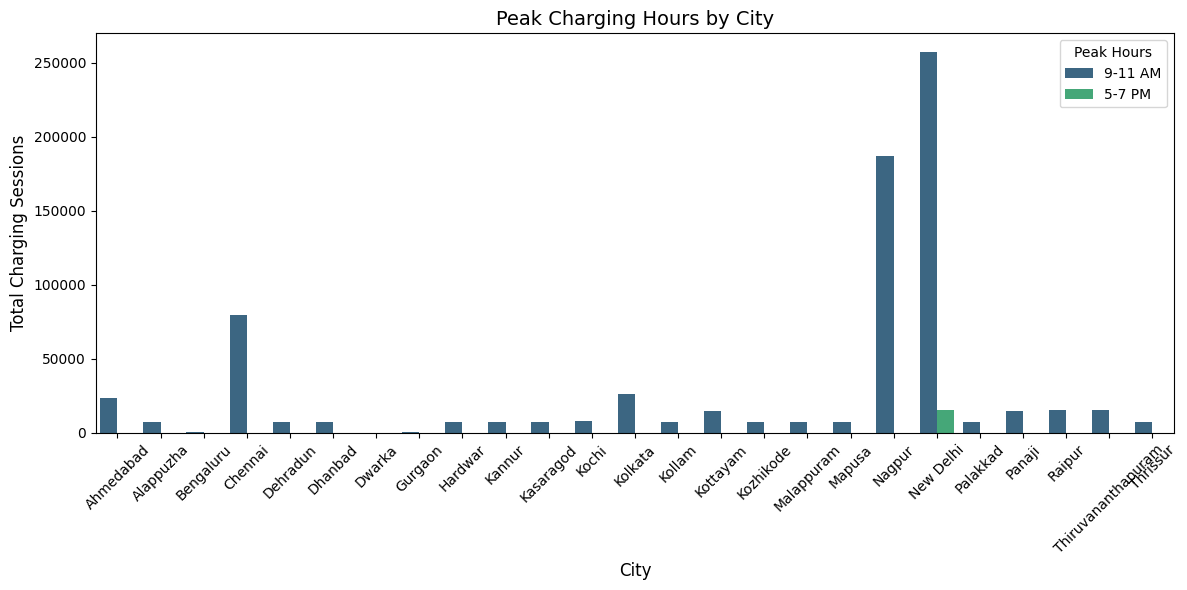

In [ ]:

plt.figure(figsize=(12, 6))
sns.barplot(
    data=peak_hours_analysis,
    x='city',
    y='charging_sessions',
    hue='peak_hours',
    palette='viridis'
)
plt.xlabel('City', fontsize=12)
plt.ylabel('Total Charging Sessions', fontsize=12)
plt.title('Peak Charging Hours by City', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Peak Hours', fontsize=10)
plt.tight_layout()
plt.show()


In [ ]:

def assign_user_type(row):
    vehicle_type = row['vehicle_type']
    vendor_name = row['vendor_name']
    if not isinstance(vehicle_type, list):
        try:
            vehicle_type = eval(vehicle_type)
        except (TypeError, SyntaxError):
            vehicle_type = [vehicle_type]

    if '2W' in vehicle_type and '4W' not in vehicle_type:
        return 'private vehicle'
    elif '4W' in vehicle_type and vendor_name.lower() == 'blusmart':
        return 'ride-sharing'
    elif '3W' in vehicle_type or len(vehicle_type) > 1:
        return 'fleet'
    else:
        return 'private vehicle'

df['user_type'] = df.apply(assign_user_type, axis=1)

# Assign user type
df['user_type'] = df.apply(assign_user_type, axis=1)

# Group by user type to analyze distribution
user_type_distribution = df['user_type'].value_counts().reset_index()
user_type_distribution.columns = ['user_type', 'count']

print("User Type Distribution:")
print(user_type_distribution)

station_user_type = df[['uid', 'city', 'user_type']]
print("\nStation-wise User Type:")
print(station_user_type)


User Type Distribution:
         user_type  count
0  private vehicle   2655
1            fleet     41
2     ride-sharing      9

Station-wise User Type:
           uid       city        user_type
0     STATIC12  New Delhi  private vehicle
1     STATIC14  New Delhi            fleet
2     STATIC15  New Delhi  private vehicle
3     STATIC16  New Delhi  private vehicle
4     STATIC17  New Delhi     ride-sharing
...        ...        ...              ...
2700      1028    Chennai  private vehicle
2701      1028    Chennai  private vehicle
2702      1028    Chennai  private vehicle
2703    BSES-1  New Delhi  private vehicle
2704    BSES-1  New Delhi            fleet

[2705 rows x 3 columns]


In [ ]:
# Group by user_type and calculate total charging sessions
user_type_analysis = df.groupby('user_type')['charging_sessions'].sum().reset_index()

# Sorting to find the most dominant user type
user_type_analysis = user_type_analysis.sort_values(by='charging_sessions', ascending=False)

print("User Type Analysis:")
print(user_type_analysis)


User Type Analysis:
         user_type  charging_sessions
1  private vehicle             742026
0            fleet               4124
2     ride-sharing               2016


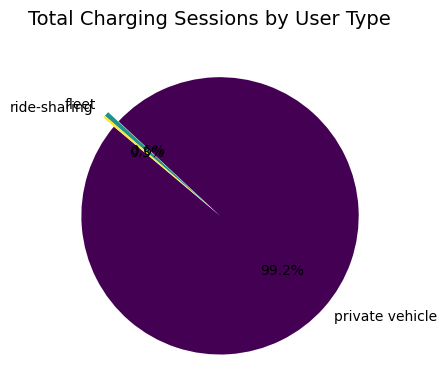

In [ ]:

plt.figure(figsize=(6, 4))

labels = user_type_analysis['user_type']
sizes = user_type_analysis['charging_sessions']
explode = [0.1 if i == sizes.max() else 0 for i in sizes]

plt.pie(
    sizes,
    explode=explode,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.viridis(np.linspace(0, 1, len(labels))),
)
plt.title('Total Charging Sessions by User Type', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# average energy consumption per session based on charger type
def get_energy_per_session(power_type):
    if power_type == 'DC':
        return 25  # 25 kWh per session for DC chargers
    elif power_type == 'AC':
        return 7.5  # 7.5 kWh per session for AC chargers
    else:
        return 10  # Default assumption for unknown types

#column for energy per session
df['energy_per_session'] = df['power_type'].apply(get_energy_per_session)

# energy consumed
df['energy_consumed'] = df['charging_sessions'] * df['energy_per_session']

df['energy_consumed'] = df['energy_consumed'].fillna(0)

# Display results
energy_consumption_analysis = df[['uid', 'city', 'charging_sessions', 'energy_consumed']]
print("Energy Consumption Analysis:")
print(energy_consumption_analysis)


Energy Consumption Analysis:
           uid       city  charging_sessions  energy_consumed
0     STATIC12  New Delhi                288           7200.0
1     STATIC14  New Delhi                 48            360.0
2     STATIC15  New Delhi                288           7200.0
3     STATIC16  New Delhi                288           7200.0
4     STATIC17  New Delhi                288           7200.0
...        ...        ...                ...              ...
2700      1028    Chennai                288           7200.0
2701      1028    Chennai               2725          68125.0
2702      1028    Chennai               2725          68125.0
2703    BSES-1  New Delhi                107            802.5
2704    BSES-1  New Delhi                 48            360.0

[2705 rows x 4 columns]


In [ ]:
# average energy consumed per session for each station
df['average_energy_per_session'] = df['energy_consumed'] / df['charging_sessions']

# relevant columns
average_energy_analysis = df[['uid', 'average_energy_per_session']]

print("Average Energy Consumption per Session:")
print(average_energy_analysis)


Average Energy Consumption per Session:
           uid  average_energy_per_session
0     STATIC12                        25.0
1     STATIC14                         7.5
2     STATIC15                        25.0
3     STATIC16                        25.0
4     STATIC17                        25.0
...        ...                         ...
2700      1028                        25.0
2701      1028                        25.0
2702      1028                        25.0
2703    BSES-1                         7.5
2704    BSES-1                         7.5

[2705 rows x 2 columns]


In [ ]:
df['open']

,open
0,2025-02-16
1,2025-02-16
2,2025-02-16
3,2025-02-16
4,2025-02-16
...,...
2700,2025-02-16
2701,2025-02-16
2702,2025-02-16
2703,2025-02-16


In [ ]:

df['available'] = df['available'].apply(lambda x: min(max(x, 0), 1) if pd.notnull(x) else 1.0)

# Function to calculate total operational hours
def calculate_operational_hours(row):
    try:
        open_time = row['open']
        close_time = row['close']
        if close_time < open_time:
            return 24  # Full 24 hours if data is invalid
        return (close_time - open_time).seconds / 3600  # seconds to hours
    except:
        return 24  # Default to 24 hours if there are any errors

# column for operational hours
df['operational_hours'] = df.apply(calculate_operational_hours, axis=1)

df['downtime'] = df['operational_hours'] * (1 - df['available'])

# Replace negative or invalid downtime with 0
df['downtime'] = df['downtime'].apply(lambda x: max(x, 0))

downtime_analysis = df[['uid', 'city', 'operational_hours', 'available', 'downtime']]
print("Downtime Analysis:")
print(downtime_analysis)


Downtime Analysis:
           uid       city  operational_hours  available   downtime
0     STATIC12  New Delhi          23.999722        1.0   0.000000
1     STATIC14  New Delhi          23.999722        1.0   0.000000
2     STATIC15  New Delhi          23.999722        1.0   0.000000
3     STATIC16  New Delhi          23.999722        1.0   0.000000
4     STATIC17  New Delhi          23.999722        1.0   0.000000
...        ...        ...                ...        ...        ...
2700      1028    Chennai          23.983333        0.0  23.983333
2701      1028    Chennai          23.983333        0.0  23.983333
2702      1028    Chennai          23.983333        0.0  23.983333
2703    BSES-1  New Delhi          23.999722        1.0   0.000000
2704    BSES-1  New Delhi          23.999722        1.0   0.000000

[2705 rows x 5 columns]


In [ ]:
# Sort stations by downtime to identify the ones with the highest
highest_downtime = df[['uid', 'downtime', 'charging_sessions']].sort_values(by='downtime', ascending=False)

print("Stations with Highest Downtime:")
print(highest_downtime)

# Potential reasoning based on low charging_sessions
highest_downtime['possible_reason'] = highest_downtime['charging_sessions'].apply(
    lambda x: "Low Usage" if x < 10 else "Operational Issues"
)

print("Stations with Possible Reasons for Downtime:")
print(highest_downtime)


Stations with Highest Downtime:
                   uid   downtime  charging_sessions
84             EESL577  23.999722                288
45             EESL397  23.999722                288
137           EESL1386  23.999722                422
136           EESL1385  23.999722                288
135           EESL1385  23.999722                422
...                ...        ...                ...
937   REVBOLT_00021060   0.000000                  0
938   REVBOLT_00023617   0.000000                  0
939     REVBOLT_004167   0.000000                  0
940   REVBOLT_00021137   0.000000                  0
2704            BSES-1   0.000000                 48

[2705 rows x 3 columns]
Stations with Possible Reasons for Downtime:
                   uid   downtime  charging_sessions     possible_reason
84             EESL577  23.999722                288  Operational Issues
45             EESL397  23.999722                288  Operational Issues
137           EESL1386  23.999722          

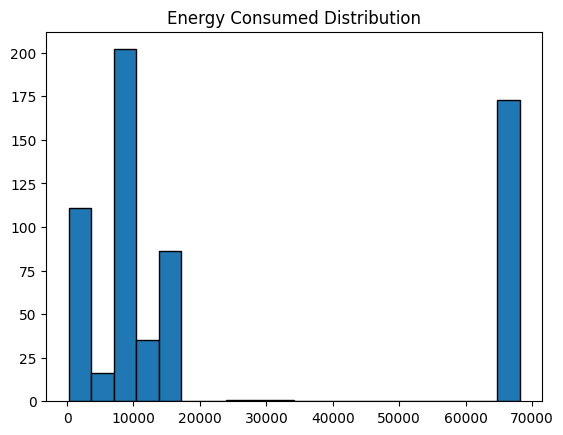

In [ ]:
import matplotlib.pyplot as plt
plt.hist(y, bins=20, edgecolor='k')
plt.title("Energy Consumed Distribution")
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Create a copy of the dataframe to avoid modifying the original
df_cleaned = df.copy()

# Identify rows with non-zero energy_consumed
non_zero_energy = df_cleaned[df_cleaned['energy_consumed'] > 0]

# Identify rows with zero or missing energy_consumed
zero_energy = df_cleaned[df_cleaned['energy_consumed'] <= 0]

# Prepare features and target for regression
X_train = non_zero_energy[['charging_sessions', 'capacity']]  # Features
y_train = non_zero_energy['energy_consumed']  # Target

# Train a Linear Regression model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predict `energy_consumed` for rows with zero or missing values
X_missing = zero_energy[['charging_sessions', 'capacity']]
predicted_energy = regressor.predict(X_missing)

# Ensure predictions are non-negative (if any negative predictions occur, set to zero)
predicted_energy = np.maximum(predicted_energy, 0)

# Impute the predicted values into the original dataframe
df_cleaned.loc[zero_energy.index, 'energy_consumed'] = predicted_energy

# Verify the updated dataframe
print(df_cleaned[['charging_sessions', 'capacity', 'energy_consumed']].head(10))


   charging_sessions  capacity  energy_consumed
0                288      15.0           7200.0
1                 48       3.3            360.0
2                288      15.0           7200.0
3                288      15.0           7200.0
4                288      15.0           7200.0
5                 48       3.3            360.0
6                288      15.0           7200.0
7                 48       3.3            360.0
8                 48       3.3            360.0
9                576      30.0          14400.0


In [ ]:
print(df[['charging_sessions', 'downtime', 'capacity', 'energy_consumed']].corr())


                   charging_sessions  downtime  capacity  energy_consumed
charging_sessions           1.000000  0.429261  0.988760         0.941230
downtime                    0.429261  1.000000  0.416612         0.395940
capacity                    0.988760  0.416612  1.000000         0.883804
energy_consumed             0.941230  0.395940  0.883804         1.000000


In [ ]:
from catboost import CatBoostRegressor

# Train a CatBoost Regressor model
cat_model = CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
cat_model.fit(X_train, y_train)

# Predict energy consumption
y_pred = cat_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

next_day_prediction_log = cat_model.predict(X_test.head(1))
next_day_prediction = np.expm1(next_day_prediction_log)  # Revert log transformation

# Calibrate low predictions
next_day_prediction = max(next_day_prediction, 0.5)  # Ensure a minimum realistic value
print(f"Predicted Energy Consumption for Next Day: {next_day_prediction:.2f} kWh")


Mean Absolute Error (MAE): 0.0029394580596376896
Root Mean Squared Error (RMSE): 0.04734308048816097
Predicted Energy Consumption for Next Day: 0.50 kWh


Feature Importance:
              Feature Id  Importances
0              capacity    79.554671
1     charging_sessions    14.793706
2     sessions_capacity     5.207895
3  downtime_per_session     0.279232
4              downtime     0.164496


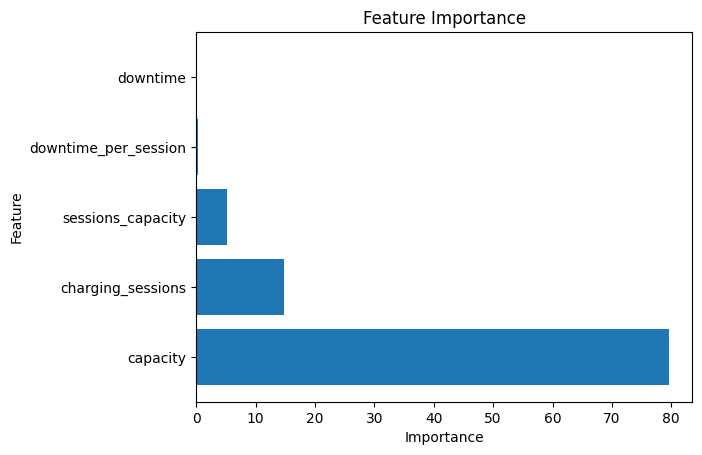

Mean Absolute Error (MAE): 5.722902741575305
Root Mean Squared Error (RMSE): 80.65095884380933
Predicted Energy Consumption for Next Day: 0.50 kWh


In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

# Feature Engineering: Add Interaction Terms
df['sessions_capacity'] = df['charging_sessions'] * df['capacity']
df['downtime_per_session'] = df['downtime'] / (df['charging_sessions'] + 1e-6)

# Log-transform the target variable
df['log_energy_consumed'] = np.log1p(df['energy_consumed'])

# Normalize features
scaler = MinMaxScaler()
features = ['charging_sessions', 'downtime', 'capacity', 'sessions_capacity', 'downtime_per_session']
X = pd.DataFrame(scaler.fit_transform(df[features]), columns=features)
y = df['log_energy_consumed']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the optimized CatBoost model
cat_model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
cat_model.fit(X_train, y_train)

# Feature Importance
feature_importances = cat_model.get_feature_importance(prettified=True)
print("Feature Importance:\n", feature_importances)

# Plot feature importance
plt.barh(feature_importances['Feature Id'], feature_importances['Importances'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

# Predict on the log scale
y_pred_log = cat_model.predict(X_test)

# Revert the log transformation
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# Evaluate the model
mae = mean_absolute_error(y_test_original, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Predict energy consumption for the next day
next_day_prediction_log = cat_model.predict(X_test.head(1))
next_day_prediction = np.expm1(next_day_prediction_log)  # Revert log transformation

# Calibrate low predictions
next_day_prediction = max(next_day_prediction, 0.5)  # Ensure a minimum realistic value
print(f"Predicted Energy Consumption for Next Day: {next_day_prediction:.2f} kWh")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

So , we can see that CatBoost has provided us with better results as compare to XGBoost.
